In [1]:
include("Stability.jl")
include("CRD_STA.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using PyCall
using BSplineKit

In [2]:
function eigsol(F,G,H,T,R,omega,be,N_cheb,D,D2,c,num)
    sigma = 0.72
    cof = CRC_STA.Spatial_mode_BEK(F,-G,H,T,sigma,N_cheb,D,D2,R)
    A0_raw,A1_raw,A2_raw = CRC_STA.assemble_mat(cof :: CRC_STA.COF,D,D2,be,omega,R)
    A0,A1,A2 = CRC_STA.boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
    # eigval = conj(eigval)
    return eigval,eigvec
end

eigsol (generic function with 1 method)

In [3]:
function ODE(N_cheb,Ro)
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    return u0,v0,w0,f,q,D,D2,x
end
function BF(N_cheb,Tw,Mr,u0,v0,w0,f,q,D,D2,x)
    gamma = 1.4
    sigma = 0.72
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"phy")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,z,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    sigma = 0.72
    gamma = 1.4
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    A0_raw,A1_raw,A2_raw = assemble_mat(cof :: COF,D,D2,be,omega)
    A0,A1,A2 = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-12)
    # eigval = conj(eigval)
    return eigval
end

eigsol (generic function with 2 methods)

In [4]:
function interp(u0,v0,w0,T0,x,N)
    F = zeros(N+1)
    G = zeros(N+1)
    H = zeros(N+1)
    T = zeros(N+1)

    z = range(0, 20, 2000)

    itu = BSplineKit.interpolate(z, u0, BSplineOrder(4))
    itv = BSplineKit.interpolate(z, v0, BSplineOrder(4))
    itw = BSplineKit.interpolate(z, w0, BSplineOrder(4))
    itt = BSplineKit.interpolate(z, T0, BSplineOrder(4))

    for i in 1:N+1
        F[i] = itu(x[i])
        G[i] = itv(x[i])
        H[i] = itw(x[i])
        T[i] = itt(x[i])
    end

    return F, G, H, T
end

interp (generic function with 2 methods)

In [ ]:
N_cheb = 199
Ro = -1.0
Tw = 1.1
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
be = 0.07759
num = 1
omega = 0.0
R = 280
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = ODE(N_cheb,Ro)
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Tw,Mr,u0,v0,w0,f,q,D,D2,x)

In [5]:
Tw = 1.1
pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
bone = pyimport("Bone")
z_1, H_1, F_1, G_1, T_1, dF, dG, dT, info = bone.get_baseflow(Tw)

([0.0, 0.010005002501250625, 0.02001000500250125, 0.030015007503751877, 0.0400200100050025, 0.05002501250625312, 0.060030015007503754, 0.07003501750875438, 0.080040020010005, 0.09004502251125562  …  19.909954977488745, 19.919959979989994, 19.929964982491246, 19.939969984992494, 19.949974987493746, 19.959979989995, 19.969984992496247, 19.9799899949975, 19.989994997498748, 20.0], [7.598392701516869e-24, -5.691190122123911e-5, -0.00022619678481613158, -0.0005056873449415697, -0.0008932520574212161, -0.001386777091194541, -0.0019841839145457963, -0.002683411449020372, -0.003482433423240102, -0.004379240775842994  …  -1.0898391855498, -1.089839185687285, -1.0898391858079384, -1.0898391859119383, -1.0898391859994605, -1.0898391860706818, -1.0898391861257777, -1.0898391861649197, -1.08983918618828, -1.0898391861960288], [0.0, 0.005670218682521037, 0.011231678239564759, 0.016685723765755313, 0.022033688460607406, 0.027276899540097935, 0.03241667208746254, 0.03745431508928348, 0.042391125186025

In [ ]:
plot(x,G)
plot!(z_1,-G_1)

In [ ]:
plot(x,F,xlims=[0,20])
plot!(x,G)
plot!(x,H)
plot!(x,T)
plot!(z_1,F_1)
plot!(z_1,-G_1)
plot!(z_1,H_1)
plot!(z_1,T_1)


In [6]:
R = 285.365
omega = 0.0
be = 0.07759
Tw = 1.1
alpha_ref = 0.384 + 0im
pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
bone = pyimport("Bone")
z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)
N_cheb = 99
c_ini = 0.3
num = 3
DM,D2M,x = CRC_STA.cheb_points(N_cheb)
F,G,H,T = interp(F,G,H,T,x,N_cheb)
val,vec = eigsol(F,G,H,T,R,omega,be,N_cheb,DM,D2M,c_ini,num)

(ComplexF64[0.331044028688152 - 0.004879893976948739im, 0.20933243775780103 + 0.04497318263499752im, 0.22645352992742623 + 0.0933619388465063im], ComplexF64[9.625284154378798e-5 + 0.0002244340961750787im 0.00017826440556200377 + 4.83886667937947e-5im 2.1754539018764866e-5 + 9.001931692107109e-7im; 0.00038520255335344874 + 0.000893993094503705im 0.0007118499799334892 + 0.00019215851766656814im 8.824970658692199e-5 + 3.7304431629200806e-6im; … ; 2.8548059641080037e-16 + 6.712837750944001e-16im -4.4338924892750597e-13 - 5.994000868564386e-13im 1.4911726389267577e-10 + 5.055143421917041e-10im; -1.4456990045352622e-17 - 4.3858967960652787e-17im 1.2491238927436411e-12 + 2.9416551853414236e-12im -2.571049971449016e-10 - 2.0826937944585363e-9im])

In [ ]:
plot(abs.(vec[:,1]))

In [ ]:
R_ini = 500
omega = 0.0
be_ini = 0.04
c_ini = 0.1
Tw = 1.1
num = 2
pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
bone = pyimport("Bone")
z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)
N_cheb = 69
DM,D2M,x = CRC_STA.cheb_points(N_cheb)
F,G,H,T = interp(F,G,H,T,x,N_cheb)
cur(Tw,omega,R_ini,c_ini,be_ini,num)

In [ ]:
function cur(Tw,omega,R_ini,c_ini,be_ini,num)
    be_step = -0.0005
    pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
    bone = pyimport("Bone")
    z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)
    N_cheb = 99
    DM,D2M,x = CRC_STA.cheb_points(N_cheb)
    F,G,H,T = interp(F,G,H,T,x,N_cheb)
    initial = []
    tempvec_1 = [0 0 0 0 0 0 0]
    eigval = 0
    writedlm("output.dat",initial)
    writedlm("output_eig.dat",initial)
    eigval_ori,eigvec = eigsol(F,G,H,T,R_ini,omega,be_ini,N_cheb,DM,D2M,c_ini,num)
    open("output_eig.dat", "a") do io
        write(io,"be=$be_ini,eig=$eigval_ori\n")
    end
    # eigval = sort(eigval_ori, by=real)
    if imag(eigval_ori[1]) < 0
        for be = be_ini :  be_step : -0.5
            sig_last1 = sign(imag(eigval[1]))
            sig_last2 = sign(imag(eigval[end]))
            eigval,eigvec = eigsol(F,G,H,T,R_ini,omega,be,N_cheb,DM,D2M,c_ini,num)
            sig_now1 = sign(imag(eigval[1]))
            sig_now2 = sign(imag(eigval[end]))
            # point = filter(x -> abs(imag(x)) < 0.0004 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if sig_last1 * sig_now1 < 0 || sig_last2 * sig_now2 < 0
                initial = [omega R_ini be real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])]
                break
            end
        end
    elseif imag(eigval_ori[1]) > 0
        for be = be_ini : - be_step : 0.5
           sig_last1 = sign(imag(eigval[1]))
            sig_last2 = sign(imag(eigval[end]))
            eigval,eigvec = eigsol(F,G,H,T,R_ini,omega,be,N_cheb,DM,D2M,c_ini,num)
            sig_now1 = sign(imag(eigval[1]))
            sig_now2 = sign(imag(eigval[end]))
            # point = filter(x -> abs(imag(x)) < 0.0004 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if sig_last1 * sig_now1 < 0 || sig_last2 * sig_now2 < 0
                initial = [omega R_ini be real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])]
                break
            end
        end
    end
    total = initial
    be = initial[3] - be_step
    dir = 0
    boundlen = 3
 # CACULATE

    while true
        index = findall(x->x==findmin([total[end,5],total[end,7]])[1],total[end,:])
        c = total[end,index[1] - 1]
        eigval,eigvec = eigsol(F,G,H,T,total[end,2],omega,be,N_cheb,DM,D2M,c,num)
        eigval_1,eigvec = eigsol(F,G,H,T,total[end,2],omega,be-0.001,N_cheb,DM,D2M,c,num)
        eigval_2,eigvec =  eigsol(F,G,H,T,total[end,2],omega,be+0.001,N_cheb,DM,D2M,c,num)
        index1 = findmin(x-> (imag(x)) , eigval_1)[2]
        index2 = findmin(x-> (imag(x)) , eigval_2)[2]
        num = 1
        if size(total,1) > 3 && abs(total[end,2] - total[end-1,2]) <=2
            R_step = 0.25
        else
            R_step = 1
        end
        if (imag(eigval_1[index1]) < 0 && imag(eigval_2[index2]) > 0) || (imag(eigval_1[index1]) > 0 && imag(eigval_2[index2]) > 0) || dir == -1
            mode = 1
        elseif (imag(eigval_1[index1]) > 0 && imag(eigval_2[index2]) < 0) || (imag(eigval_1[index1]) < 0 && imag(eigval_2[index2]) < 0)
            mode = 2
        end
        
        if mode == 1 

            for R = total[end,2] : R_step : 700

                eigval,eigvec = eigsol(F,G,H,T,R,omega,be,N_cheb,DM,D2M,c,num)
                index = findmin((imag),eigval)[2]

                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     
                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end

                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end


        if mode == 2

            for R = total[end,2]: -R_step : 0
                
                eigval,eigvec = eigsol(F,G,H,T,R,omega,be,N_cheb,DM,D2M,c,num)
                index = findmin((imag),eigval)[2]
                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     
                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end
                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
                
                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 1
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end

        if mode == 1

            for R = total[end,2]: R_step : 700

                if total[end,3] == be

                    break

                end 
                
                eigval,eigvec = eigsol(F,G,H,T,R,omega,be,N_cheb,DM,D2M,c,num)
                index = findmin((imag),eigval)[2]
                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     

                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
                
                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end
        c = total[end,4]
        eigval,eigvec = eigsol(F,G,H,T,total[end,2] + 2,omega,be,N_cheb,DM,D2M,c,num)
        sig = findmin(imag,eigval)[1]
        if size(total,1) > 10 &&total[end,3] != be 
            dir = -1 
            be_step = 0.0009
        else
            if sig > 0
                dir = -1
                be_step = 0.00075
            else
                dir = 1
                be_step = 0.00075
            end
        end
            be += 0.0008
        filename = "ome=$(omega)_Tw=$(Tw).dat"
        str1 = "Variables=\"omega\" \"R\" \"beta\" \"alpha_r_1\" \"alpha_i_1\" \"alpha_r_2\" \"alpha_i_2\""
        str2 = "Zone T=\"omega=$(omega),Tw=$(Tw)\""
        open(filename,"w") do io
            println(io,str1)
            println(io,str2)
            writedlm(io,total[2:end,:])
        end
        if total[end,2] > 500 && size(total,1) > 30 
            break
        end
        # app = readdlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr)_temp.dat")
        # ori = readdlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat")
        # if app[end,2] < ori[3,2]
        #     break
        # end
    end
end

## Sutherland base flow at specified Tw, Mr, and R

Set `Tw_suth`, `Mr_suth`, and `R_suth` below, then run the next cells to generate and visualize the Sutherland-viscosity base-flow profile at that radial position.  Set `save_outputs_suth = true` only when CSV and metadata files are needed.


In [64]:
using Printf
using Plots

# User parameters for the Sutherland marching solver.
Tw_suth = 1.4
Mr_suth = 0.3
R_suth = 200.0

# Numerical controls. Increase Nr/Nz for final data or grid-convergence checks.
r0_suth = 1.0
Nr_suth = 41
Nz_suth = 81
zmax_suth = 20.0
newton_tol_suth = 1.0e-8
newton_maxiter_suth = 14

# Set this to true only when CSV/metadata files are needed.
save_outputs_suth = false

out_dir_suth = @sprintf("sutherland_Tw%.3g_Mr%.3g_R%.3g", Tw_suth, Mr_suth, R_suth)
Minf_suth = Mr_suth / R_suth

nothing


In [65]:
# Run the Sutherland solver inside the notebook.
include("SutherlandMarching.jl")
Suth = SutherlandMarching

p_suth = Suth.Params(
    Tw = Tw_suth,
    Minf = Minf_suth,
    r0 = r0_suth,
    rmax = R_suth,
    Nr = Nr_suth,
    zmax = zmax_suth,
    Nz = Nz_suth,
    newton_tol = newton_tol_suth,
    newton_maxiter = newton_maxiter_suth,
    out_dir = out_dir_suth,
    verbose = false,
)

r_values_suth, z_suth, stations_suth = Suth.solve_marching(p_suth)

profile_all_suth = nothing
profile_R_suth = nothing
summary_suth = nothing
metadata_suth = nothing
if save_outputs_suth
    profile_all_suth, profile_R_suth, summary_suth, metadata_suth = Suth.write_outputs(r_values_suth, z_suth, stations_suth, p_suth)
end

st_R_suth = stations_suth[end]
U_suth = st_R_suth.U
V_suth = st_R_suth.V
W_suth = st_R_suth.W
T_suth = st_R_suth.T
rho_suth = Suth.suth_rho.(T_suth)
mu_suth = [Suth.suth_mu(Tj, p_suth) for Tj in T_suth]
kappa_suth = mu_suth ./ p_suth.sigma
u_physical_suth = R_suth .* U_suth
v_rotating_physical_suth = R_suth .* V_suth
v_inertial_physical_suth = R_suth .* (V_suth .+ 1.0)

println("Sutherland profile generated in memory at R = ", R_suth, ", Mr(R) = ", Minf_suth * R_suth, ", Tw = ", Tw_suth)
if save_outputs_suth
    println("Target profile: ", profile_R_suth)
    println("All profiles:    ", profile_all_suth)
    println("Summary:         ", summary_suth)
    println("Metadata:        ", metadata_suth)
end

nothing


Sutherland profile generated in memory at R = 200.0, Mr(R) = 0.3, Tw = 1.4


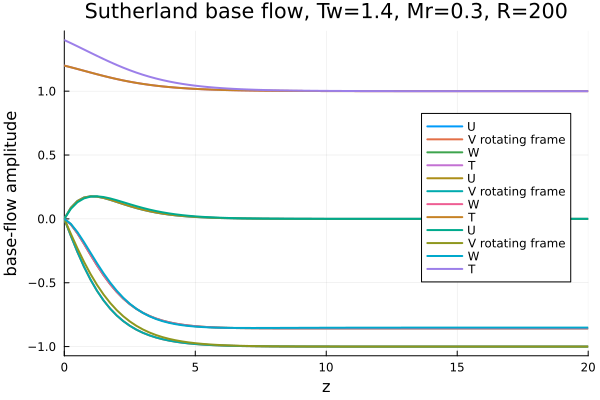

In [66]:
# Plot dimensionless profile amplitudes at the specified radius.
plot!(z_suth, U_suth, lw=2, label="U", xlabel="z", ylabel="base-flow amplitude",
     title=@sprintf("Sutherland base flow, Tw=%.3g, Mr=%.3g, R=%.3g", Tw_suth, Mr_suth, R_suth),
     xlims=(0, zmax_suth), legend=:right)
plot!(z_suth, V_suth, lw=2, label="V rotating frame")
plot!(z_suth, W_suth, lw=2, label="W")
plot!(z_suth, T_suth, lw=2, label="T")


In [ ]:
# Plot physical radial and azimuthal velocities at the specified radius.
plot(z_suth, u_physical_suth, lw=2, label="u = R U", xlabel="z", ylabel="physical velocity scale",
     title=@sprintf("Physical velocities at R=%.3g", R_suth), xlims=(0, zmax_suth), legend=:right)
plot!(z_suth, v_rotating_physical_suth, lw=2, label="v_rot = R V")
plot!(z_suth, v_inertial_physical_suth, lw=2, label="v_inertial = R(V+1)")


In [ ]:
# Plot material-property profiles used by the Sutherland model.
plot(z_suth, rho_suth, lw=2, label="rho", xlabel="z", ylabel="property",
     title="Sutherland material-property profiles", xlims=(0, zmax_suth), legend=:right)
plot!(z_suth, mu_suth, lw=2, label="mu")
plot!(z_suth, rho_suth .* mu_suth, lw=2, label="rho*mu")
plot!(z_suth, kappa_suth, lw=2, label="kappa = mu/sigma")
